H- and J-dimers, on the other hand, show different intensity profiles owing to phonon-assisted excitation and relaxation between the bright and the dark states. The bright state population of the J-dimer is higher than that of the H-dimer at early times, having its dark state energetically higher and less accessible. By contrast, the intensity of the H-dimer rapidly decays, owing to vibrationally assisted transition of excitations from the bright to the dark state.

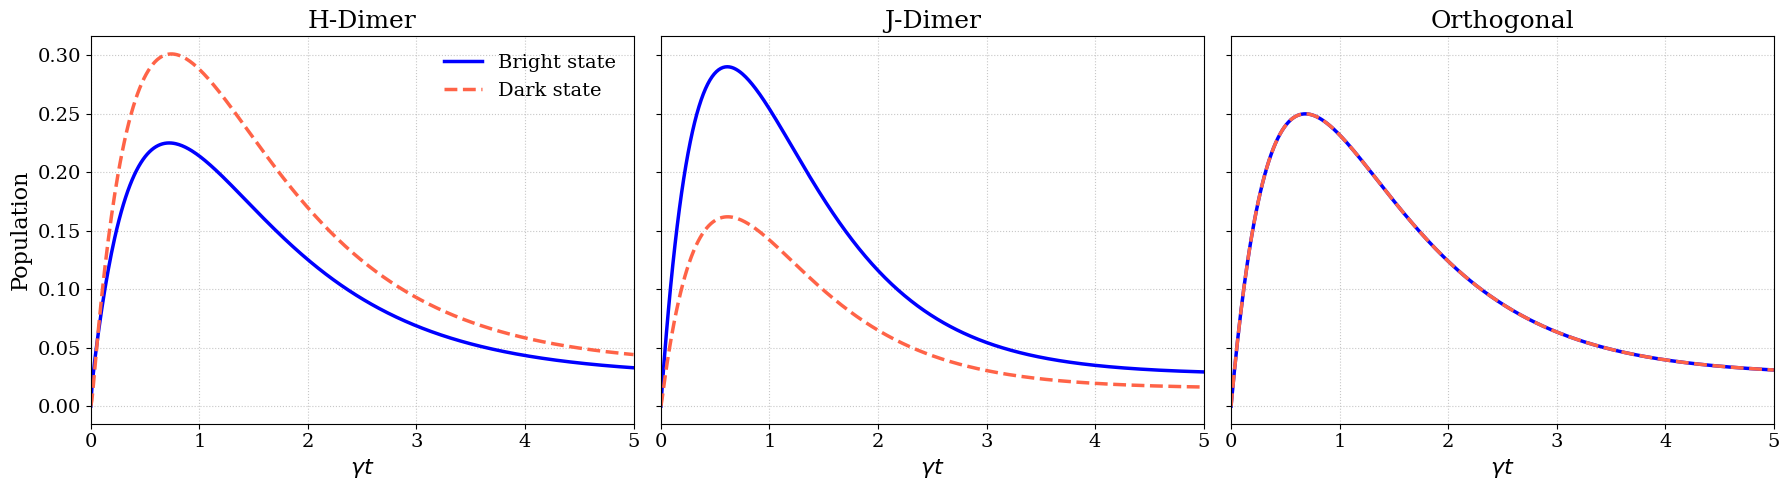

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sys_params import Constants, ConfigParameters, SystemParameters
from system_ops import SystemOperators
from rates import CombinedRates
from br_tensor import BlochRedfieldCalculator
from analysis import CoreAnalysis

mpl.rcParams['text.usetex'] = False

# Configurations for the 3-panel plot
configs = ["H", "J", "ortho"]
titles = ["H-Dimer", "J-Dimer", "Orthogonal"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
constants = Constants()

for idx, conf in enumerate(configs):
    # 1. System Initialization
    config = ConfigParameters(
        config_name=conf, 
        mode="polaron", 
        pump="none", 
        integration_method="vectorised",
        data_dir="files/dipole_positions/" 
    )
    
    sys_params = SystemParameters(
        constants=constants, 
        config_params=config, 
        E_q1_eV=1.8, 
        E_q2_eV=1.8,
        T_opt=5800.0,
        T_vib=300.0
    )
    sys_params.calculate_parameters()
    
    # 2. Rates & Operators
    rates = CombinedRates(sys_params)
    sys_ops = SystemOperators(sys_params, rates)
    
    psi0 = np.array([1, 0, 0, 0], dtype=complex)
    _, rho0 = sys_ops.initial_state(psi0)
    
    a_ops_opt = [sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2]
    a_ops_vib = [sys_ops.sz1, sys_ops.sz2]
    a_ops_coup = [sys_ops.sp1 @ sys_ops.sm2, sys_ops.sm1 @ sys_ops.sp2]
    
    # 3. Superoperator Generation
    br_calc = BlochRedfieldCalculator(
        system_params=sys_params,
        rates=rates,
        H=sys_ops.H,
        a_ops_opt=a_ops_opt,
        Gamma_opt=rates.Opt_rate(),
        a_ops_vib=a_ops_vib,
        Gamma_vib=rates.Vib_rate(),
        a_ops_coup=a_ops_coup,
        Gamma_coup=rates.Coup_rate(),
        P_vib=rates.P_weight()
    )
    
    # 4. CoreAnalysis Engine (Transient Dynamics)
    tf_transient = 5.0 * sys_params.tau_L1
    steps_transient = 500
    
    core = CoreAnalysis(
        system_params=sys_params, 
        BR_calculator=br_calc, 
        rates=rates, 
        final_time=tf_transient, 
        steps=steps_transient, 
        rho_init=rho0, 
        ss_method=None
    )
    
    # 5. Extract Populations
    pop_br = core.calculate_population('bright')
    pop_d = core.calculate_population('dark')
    times_norm = sys_params.gamma_q1 * core.times
    
    # 6. Plotting
    axes[idx].plot(times_norm, pop_br, color='blue', linewidth=2.5, label='Bright state')
    axes[idx].plot(times_norm, pop_d, color='tomato', linestyle='--', linewidth=2.5, label='Dark state')
    
    axes[idx].set_title(titles[idx], fontsize=18)
    axes[idx].set_xlabel(r'$\gamma t$', fontsize=16)
    axes[idx].tick_params(axis='both', labelsize=14)
    axes[idx].set_xlim([0, times_norm[-1]])
    axes[idx].grid(True, linestyle=':', alpha=0.7)
    
    if idx == 0:
        axes[idx].set_ylabel('Population', fontsize=16)
        axes[idx].legend(fontsize=14, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

We plot the time-dependent intensity for three different geometric configurations of dimers in Fig. 2(d). The purple dotted line, shows the idealized case when two uncoupled quantum emitters emit collectively without vibrational effects, resulting in a distinct non-exponential dynamics in the intensity profile. H- and J-dimers, on the other hand, show different intensity profiles owing to phonon-assisted excitation and relaxation between the bright and the dark states. The bright state population of the J-dimer is higher than that of the H-dimer at early times, having its dark state energetically higher and less accessible. Overall, the J-dimer features an enhanced decay rate, which may be reduced from the ideal super-radiant case of two idealized identical emitters if vibrational excitation becomes relevant or in the presence of strong vibrational coupling also at zero temperature. By contrast, the intensity of the H-dimer rapidly decays, owing to vibrationally assisted transition of excitations from the bright to the dark state. Finally, for orthogonal dipoles, the contribution from the coherence terms in Eq. (14) vanishes owing to the cross-function $\mathcal{F}$ going to zero. Thus, upon integrating over all light modes, excitations follow two distinct channels (one for each site basis state), at the single emitter decay rate $\gamma$.

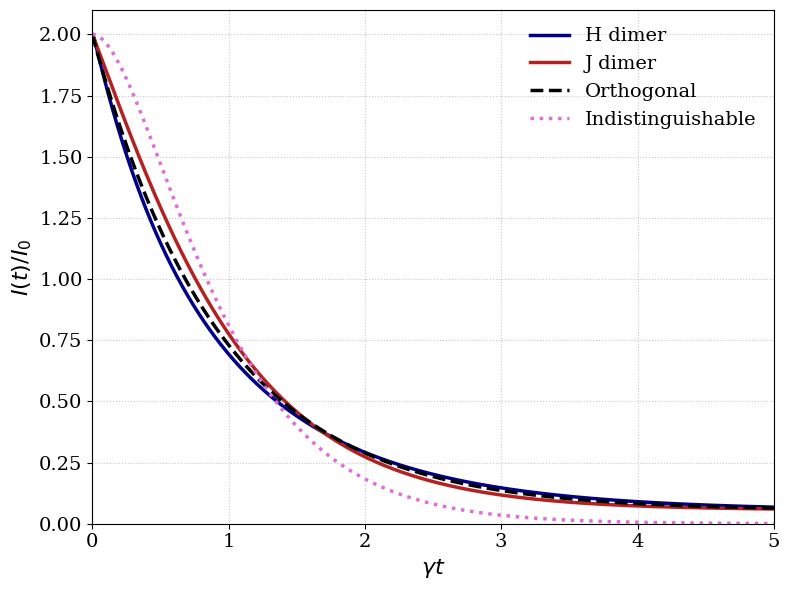

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sys_params import Constants, ConfigParameters, SystemParameters
from system_ops import SystemOperators
from rates import CombinedRates
from br_tensor import BlochRedfieldCalculator
from analysis import CoreAnalysis

mpl.rcParams['text.usetex'] = False

configs = ["H", "J", "ortho"]
colors = ["darkblue", "firebrick", "black"]
linestyles = ["-", "-", "--"]
labels = ["H dimer", "J dimer", "Orthogonal"]

fig, ax = plt.subplots(figsize=(8, 6))
constants = Constants()

for idx, conf in enumerate(configs):
    # 1. System Initialization
    config = ConfigParameters(
        config_name=conf, 
        mode="polaron", 
        pump="none", 
        integration_method="vectorised",
        data_dir="files/dipole_positions/" 
    )
    
    sys_params = SystemParameters(
        constants=constants, 
        config_params=config, 
        E_q1_eV=1.8, 
        E_q2_eV=1.8,
        T_opt=5800.0,
        T_vib=300.0
    )
    sys_params.calculate_parameters()
    
    # 2. Rates & Operators
    rates = CombinedRates(sys_params)
    sys_ops = SystemOperators(sys_params, rates)
    
    psi0 = np.array([1, 0, 0, 0], dtype=complex)
    _, rho0 = sys_ops.initial_state(psi0)
    
    a_ops_opt = [sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2]
    a_ops_vib = [sys_ops.sz1, sys_ops.sz2]
    a_ops_coup = [sys_ops.sp1 @ sys_ops.sm2, sys_ops.sm1 @ sys_ops.sp2]
    
    # 3. Superoperator Generation
    br_calc = BlochRedfieldCalculator(
        system_params=sys_params,
        rates=rates,
        H=sys_ops.H,
        a_ops_opt=a_ops_opt,
        Gamma_opt=rates.Opt_rate(),
        a_ops_vib=a_ops_vib,
        Gamma_vib=rates.Vib_rate(),
        a_ops_coup=a_ops_coup,
        Gamma_coup=rates.Coup_rate(),
        P_vib=rates.P_weight()
    )
    
    # 4. Transient CoreAnalysis Engine
    tf_transient = 5.0 * sys_params.tau_L1
    steps_transient = 1000
    
    core = CoreAnalysis(
        system_params=sys_params, 
        BR_calculator=br_calc, 
        rates=rates, 
        final_time=tf_transient, 
        steps=steps_transient, 
        rho_init=rho0, 
        ss_method=None
    )
    
    # 5. Extract Total Sptial Intensity
    intensity = core.calculate_intensity()
    times_norm = sys_params.gamma_q1 * core.times
    
    # 6. Trace Evaluation
    ax.plot(times_norm, intensity, color=colors[idx], linestyle=linestyles[idx], linewidth=2.5, label=labels[idx])

# 7. Ideal Indistinguishable Curve (Theoretical Dicke Superradiance)
gamma_t = times_norm
indistinguishable_intensity = 2 * np.exp(-2 * gamma_t) * (1 + 2 * gamma_t)
ax.plot(gamma_t, indistinguishable_intensity, color='orchid', linestyle=':', linewidth=2.5, label='Indistinguishable')

ax.set_xlabel(r'$\gamma t$', fontsize=16)
ax.set_ylabel(r'$I(t) / I_0$', fontsize=16)
ax.set_xlim([0, 5.0])
ax.set_ylim([0.0, 2.1])
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14, frameon=False, loc='upper right')
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Figure 3 shows the photon coincidence $g^{(2)}(\infty, \tau)$ for H- and J-dimers as a function of time delay $\tau$. We see that for such parallel dipoles, the q-resolved photon correlations show an anti-dip at a zero time-delay. For parallel dipoles, $g^{(2)}(\infty, \tau)$ does not depend on the photon mode being detected because even though the photons emitted along other directions are less intense, they are equally correlated. We also find that the zero-delay $g^{(2)}(\infty, 0)$ is different for different dimer configurations, owing to the different populations of the system eigenstates at steady state. We also observe a broader anti-dip for the H-dimer at short time delays, owing to a lower residual population in the bright state at short time delays.

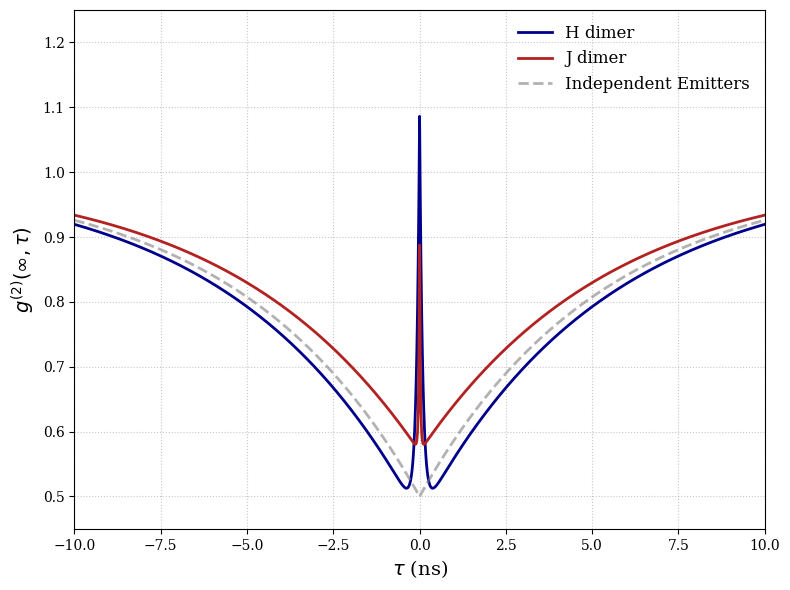

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sys_params import Constants, ConfigParameters, SystemParameters
from system_ops import SystemOperators, cart2sph
from rates import CombinedRates
from br_tensor import BlochRedfieldCalculator
from analysis import CoreAnalysis, OpticalDimerAnalysis

mpl.rcParams['text.usetex'] = False

# Override J_vib to explicitly enforce the reorganization energy
class CustomRates(CombinedRates):
    def __init__(self, system_params, E_reorg_meV=5.0):
        self.E_reorg_meV = E_reorg_meV
        super().__init__(system_params)
        
    def J_vib(self, w: float) -> float:
        omega_c = 90.0e-3 * self.constants.eV / self.constants.hbar_ps
        E_reorg = self.E_reorg_meV * 1.0e-3 * self.constants.eV / self.constants.hbar_ps
        k_vib_2 = E_reorg / (2.0 * omega_c**3)
        return (k_vib_2 * np.abs(w)**3 * np.exp(-(np.abs(w) / omega_c)))

def compute_g2(config_name: str, lambda_0_meV: float, t_final_ps: float, steps: int, independent: bool = False):
    config = ConfigParameters(
        config_name=config_name, mode="polaron", pump="sym", 
        integration_method="vectorised", data_dir="files/dipole_positions/"
    )
    sys_params = SystemParameters(
        constants=Constants(), config_params=config, 
        E_q1_eV=1.8, E_q2_eV=1.8, T_opt=5800.0, T_vib=300.0, r_nm=2.0
    )
    sys_params.calculate_parameters()
    
    # Enforce incoherent pumping equal to the optical decay rate
    sys_params.gamma_p_1 = sys_params.gamma_q1
    sys_params.gamma_p_2 = sys_params.gamma_q2
    
    rates = CustomRates(sys_params, E_reorg_meV=lambda_0_meV)
    sys_ops = SystemOperators(sys_params, rates)
    
    psi0 = np.array([1, 0, 0, 0], dtype=complex)
    _, rho0 = sys_ops.initial_state(psi0)
    
    a_ops_opt = [sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2]
    a_ops_vib = [sys_ops.sz1, sys_ops.sz2]
    a_ops_coup = [sys_ops.sp1 @ sys_ops.sm2, sys_ops.sm1 @ sys_ops.sp2]
    
    br_calc = BlochRedfieldCalculator(
        system_params=sys_params, rates=rates, H=sys_ops.H,
        a_ops_opt=a_ops_opt, Gamma_opt=rates.Opt_rate(),
        a_ops_vib=a_ops_vib, Gamma_vib=rates.Vib_rate(),
        a_ops_coup=a_ops_coup, Gamma_coup=rates.Coup_rate(),
        P_vib=rates.P_weight()
    )
    
    core = CoreAnalysis(
        system_params=sys_params, BR_calculator=br_calc, rates=rates, 
        final_time=t_final_ps, steps=steps, rho_init=rho0, ss_method='null_space'
    )
    dimer = OpticalDimerAnalysis(core)
    
    if config_name == "H":
        # Detect photons perpendicular to the dipoles
        perp_vec = np.array([0.0, 0.0, 1.0])
        _, theta_k, phi_k = cart2sph(perp_vec)
    elif config_name == "J":
        # Detect photons along the dipole axis
        para_vec = np.array([0.0, 1.0, 0.0])
        _, theta_k, phi_k = cart2sph(para_vec)
        
    # Extract unnormalized G2 and scale by the steady-state asymptote
    G2 = dimer.G2_delay(theta_k, phi_k, theta_k, phi_k)
    g2 = G2 / G2[-1]
    
    times_ps_sym = np.append(-np.flip(core.times[1:]), core.times)
    g2_sym = np.append(np.flip(g2[1:]), g2)
        
    return times_ps_sym, g2_sym, sys_params.gamma_q1

# Execute Panel (a) Extraction
t_long = 100000.0  
steps_long = 5000

t_ps_H, g2_H, gamma_q1 = compute_g2("H", 5.0, t_long, steps_long)
t_ps_J, g2_J, _ = compute_g2("J", 5.0, t_long, steps_long)

# Independent emitters baseline derived strictly through matrix propagation
g2_ind = 1.0 - 0.5 * np.exp(-2.0 * gamma_q1 * np.abs(t_ps_H))

t_ns_H = t_ps_H * 1.0e-3

# Panel (a) Figure Generation
fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(t_ns_H, g2_H, color='darkblue', linewidth=2, label='H dimer')
ax1.plot(t_ns_H, g2_J, color='firebrick', linewidth=2, label='J dimer')
ax1.plot(t_ns_H, g2_ind, color='gray', linestyle='--', alpha=0.6, linewidth=2, label='Independent Emitters')

ax1.set_xlabel(r'$\tau$ (ns)', fontsize=14)
ax1.set_ylabel(r'$g^{(2)}(\infty, \tau)$', fontsize=14)
ax1.set_xlim([-10, 10])
ax1.set_ylim([0.45, 1.25])
ax1.legend(loc='upper right', fontsize=12, frameon=False)
ax1.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Figures 3(b) and 3(c) further show the effect of strong phonon coupling on inter-emitter coherence. Increasing the phonon reorganization energy leads to faster coherence decay, resulting in a significantly narrower envelope of $g^{(2)}(\infty, \tau)$. Interestingly, the height of the anti-dip at zero-time delay stays constant. This is because the pumping rate is the same as the optical decay rate, which causes the formation of a stationary state under an "effective" infinite temperature photon bath. The zero-delay $g^{(2)}(\infty,0)$, which is fully determined by the stationary state and the measurement operators and does not depend on the system dynamic, thus remains constant. 

/tmp/ipykernel_212285/1103456242.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


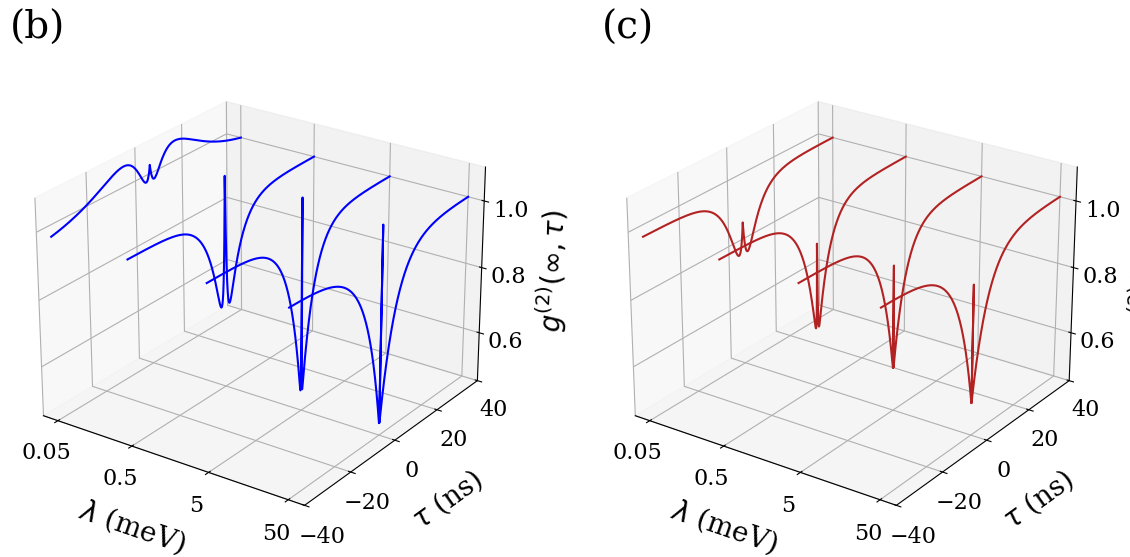

In [4]:
# Execute Panels (b) and (c) Extraction with the full 4-parameter sweep
# Note: Relies on the compute_g2() function and dependencies defined in the previous cell.

t_sim_ps = 40000.0  # 40 ns integration window
steps_sim = 5000
lambda_vals = [0.05, 0.5, 5.0, 50.0]

# Convert to log10 for visually accurate log-scale spacing in the 3D plot
log_lambda_vals = np.log10(lambda_vals)

fig = plt.figure(figsize=(14, 8))

# --- Panel (b) H-Dimer ---
ax2 = fig.add_subplot(1, 2, 1, projection='3d')
for l_val, log_l in zip(lambda_vals, log_lambda_vals):
    t_ps_H, g2_H, _ = compute_g2("H", l_val, t_sim_ps, steps_sim)
    t_ns_H = t_ps_H * 1.0e-3
    
    # Map Lambda to X-axis, Tau to Y-axis, g(2) to Z-axis
    ax2.plot(xs=np.full_like(t_ns_H, log_l), ys=t_ns_H, zs=g2_H, color='blue', linewidth=1.5)

ax2.set_xlabel(r'$\lambda$ (meV)', fontsize=20, labelpad=15)
ax2.set_ylabel(r'$\tau$ (ns)', fontsize=20, labelpad=15)
ax2.set_zlabel(r'$g^{(2)}(\infty, \tau)$', fontsize=20, labelpad=10)

ax2.set_xlim([log_lambda_vals[0] - 0.2, log_lambda_vals[-1] + 0.2])
ax2.set_xticks(log_lambda_vals)
ax2.set_xticklabels(['0.05', '0.5', '5', '50'])

ax2.set_ylim([-40, 40])
ax2.set_yticks([-40, -20, 0, 20, 40])

ax2.set_zlim([0.45, 1.1])
ax2.set_zticks([0.6, 0.8, 1.0])

ax2.set_title('(b)', fontsize=28, loc='left', pad=10)
ax2.tick_params(axis='both', labelsize=16)
ax2.view_init(elev=25, azim=-55)

# --- Panel (c) J-Dimer ---
ax3 = fig.add_subplot(1, 2, 2, projection='3d')
for l_val, log_l in zip(lambda_vals, log_lambda_vals):
    t_ps_J, g2_J, _ = compute_g2("J", l_val, t_sim_ps, steps_sim)
    t_ns_J = t_ps_J * 1.0e-3
    
    # Map Lambda to X-axis, Tau to Y-axis, g(2) to Z-axis
    ax3.plot(xs=np.full_like(t_ns_J, log_l), ys=t_ns_J, zs=g2_J, color='firebrick', linewidth=1.5)

ax3.set_xlabel(r'$\lambda$ (meV)', fontsize=20, labelpad=15)
ax3.set_ylabel(r'$\tau$ (ns)', fontsize=20, labelpad=15)
ax3.set_zlabel(r'$g^{(2)}(\infty, \tau)$', fontsize=20, labelpad=10)

ax3.set_xlim([log_lambda_vals[0] - 0.2, log_lambda_vals[-1] + 0.2])
ax3.set_xticks(log_lambda_vals)
ax3.set_xticklabels(['0.05', '0.5', '5', '50'])

ax3.set_ylim([-40, 40])
ax3.set_yticks([-40, -20, 0, 20, 40])

ax3.set_zlim([0.45, 1.1])
ax3.set_zticks([0.6, 0.8, 1.0])

ax3.set_title('(c)', fontsize=28, loc='left', pad=10)
ax3.tick_params(axis='both', labelsize=16)
ax3.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.show()

The presence of quantum correlations in the photons emitted by orthogonal emitters depends on the direction along which we collect the two subsequent photons. In Fig. 4, we consider a limiting case and show four scenarios that may arise on sampling both photons along certain common detector directions, i.e., $q=q^{\prime}$.

The polar plots in Figs. 4(a) and 4(b) show the unnormalized and normalized zero-delay photon coincidence, where, in both cases, its value goes 0.5 when both photons are detected perpendicular to the dipoles. However, the anti-dips with $g^{(2)}(\infty,0) \approx 1$ along certain sampling directions is purely a result of the normalization, which we explain further below.   

**slight issue with things in this**

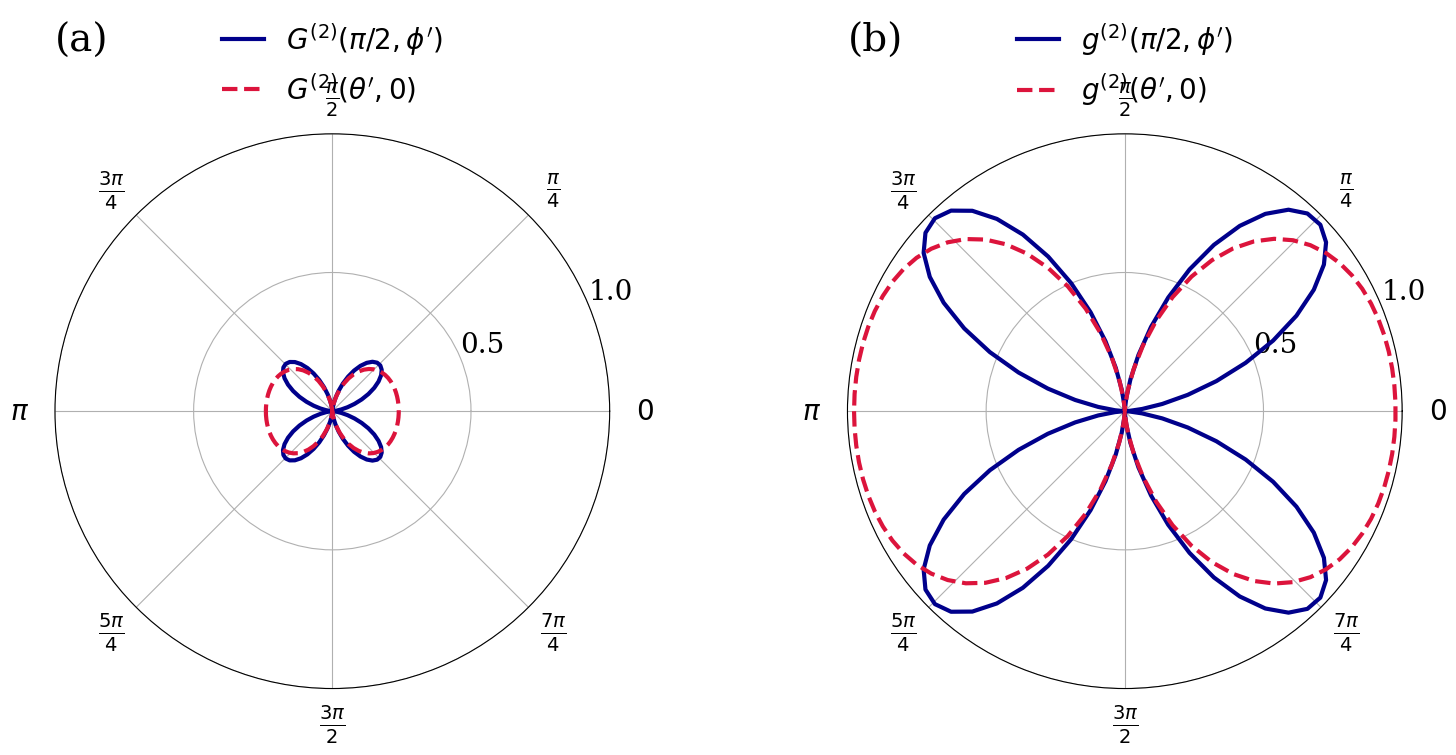

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sys_params import Constants, ConfigParameters, SystemParameters
from system_ops import SystemOperators
from rates import CombinedRates
from br_tensor import BlochRedfieldCalculator
from analysis import CoreAnalysis, OpticalDimerAnalysis

mpl.rcParams['text.usetex'] = False

config = ConfigParameters(
    config_name="ortho", 
    mode="polaron", 
    pump="sym", 
    integration_method="vectorised",
    data_dir="files/dipole_positions/" 
)

sys_params = SystemParameters(
    constants=Constants(), 
    config_params=config, 
    E_q1_eV=1.8, 
    E_q2_eV=1.8,
    T_opt=5800.0,
    T_vib=300.0
)
sys_params.calculate_parameters()

sys_params.gamma_p_1 = sys_params.gamma_q1
sys_params.gamma_p_2 = sys_params.gamma_q2

rates = CombinedRates(sys_params)
sys_ops = SystemOperators(sys_params, rates)

psi0 = np.array([1, 0, 0, 0], dtype=complex)
_, rho0 = sys_ops.initial_state(psi0)

a_ops_opt = [sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2]
a_ops_vib = [sys_ops.sz1, sys_ops.sz2]
a_ops_coup = [sys_ops.sp1 @ sys_ops.sm2, sys_ops.sm1 @ sys_ops.sp2]

br_calc = BlochRedfieldCalculator(
    system_params=sys_params, rates=rates, H=sys_ops.H,
    a_ops_opt=a_ops_opt, Gamma_opt=rates.Opt_rate(),
    a_ops_vib=a_ops_vib, Gamma_vib=rates.Vib_rate(),
    a_ops_coup=a_ops_coup, Gamma_coup=rates.Coup_rate(),
    P_vib=rates.P_weight()
)

# Extended final_time and steps to ensure G2_delay reaches its steady-state asymptote
core = CoreAnalysis(
    system_params=sys_params, BR_calculator=br_calc, rates=rates, 
    final_time=40000.0, steps=500, rho_init=rho0, ss_method='null_space'
)
dimer = OpticalDimerAnalysis(core)

n_phi_p = 100
phi_vals_p = np.linspace(0, 2 * np.pi, n_phi_p)
theta_fixed = np.pi / 2 

g2_phi = np.zeros_like(phi_vals_p)
G2_phi = np.zeros_like(phi_vals_p)

for l, phi_p in enumerate(phi_vals_p):
    G2_array = dimer.G2_delay(theta_fixed, phi_p, theta_fixed, phi_p)
    G2_phi[l] = G2_array[0]
    
    # Internal normalization: 0-delay value scaled by the steady-state asymptote
    if G2_array[-1] > 1e-12:
        g2_phi[l] = G2_array[0] / G2_array[-1]
    else:
        g2_phi[l] = 0.0

n_theta_p = 100
theta_vals_p = np.linspace(-np.pi, np.pi, n_theta_p)
phi_fixed = 0 

g2_theta = np.zeros_like(theta_vals_p)
G2_theta = np.zeros_like(theta_vals_p)

for k, theta_p in enumerate(theta_vals_p):
    G2_array = dimer.G2_delay(theta_p, phi_fixed, theta_p, phi_fixed)
    G2_theta[k] = G2_array[0]
    
    # Internal normalization: 0-delay value scaled by the steady-state asymptote
    if G2_array[-1] > 1e-12:
        g2_theta[k] = G2_array[0] / G2_array[-1]
    else:
        g2_theta[k] = 0.0

legend_fontsize = 20  
tick_fontsize = 24    
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

ticks = np.linspace(0, 2 * np.pi, 8, endpoint=False)
tick_labels = [r'$0$', r'$\frac{\pi}{4}$', r'$\frac{\pi}{2}$', r'$\frac{3\pi}{4}$',
               r'$\pi$', r'$\frac{5\pi}{4}$', r'$\frac{3\pi}{2}$', r'$\frac{7\pi}{4}$']

# --- Panel (a): Unnormalized Raw Data ---
ax1.plot(phi_vals_p, G2_phi, color='darkblue', linewidth=3, label=r'$G^{(2)}(\pi/2, \phi^{\prime})$')
ax1.plot(theta_vals_p, G2_theta, color='crimson', linewidth=3, linestyle='--', label=r'$G^{(2)}(\theta^{\prime}, 0)$')
ax1.set_thetagrids(np.degrees(ticks), labels=tick_labels, fontsize=tick_fontsize)
ax1.set_rticks([0.5, 1.0])
ax1.set_rmax(1.0)  # Locks the maximum radial limit to 1.0
ax1.tick_params(axis='both', labelsize=20, pad=15) 
ax1.set_title('(a)', loc='left', fontsize=28, pad=20)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1, labels1,
    loc='upper center',            
    bbox_to_anchor=(0.5, 1.25),    
    fontsize=legend_fontsize,      
    frameon=False,                 
    ncol=1,                        
    handlelength=1.5,                
    labelspacing=0.5,                
    markerscale=1.5                
)

# --- Panel (b): Normalized Data ---
ax2.plot(phi_vals_p, g2_phi, color='darkblue', linewidth=3, label=r'$g^{(2)}(\pi/2, \phi^{\prime})$')
ax2.plot(theta_vals_p, g2_theta, color='crimson', linewidth=3, linestyle='--', label=r'$g^{(2)}(\theta^{\prime}, 0)$')
ax2.set_thetagrids(np.degrees(ticks), labels=tick_labels, fontsize=tick_fontsize)
ax2.set_rticks([0.5, 1.0])
ax2.set_rmax(1.0)  # Locks the maximum radial limit to 1.0
ax2.tick_params(axis='both', labelsize=20, pad=15) 
ax2.set_title('(b)', loc='left', fontsize=28, pad=20)

handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    handles2, labels2,
    loc='upper center',            
    bbox_to_anchor=(0.5, 1.25),    
    fontsize=legend_fontsize,      
    frameon=False,                 
    ncol=1,                        
    handlelength=1.5,                
    labelspacing=0.5,                
    markerscale=1.5                
)

plt.tight_layout()
plt.subplots_adjust(top=0.75)
plt.show()

The four distinct regimes observed in Fig. 4(c) depend on the different states the system is projected into after detecting the first and second photon, giving rise to measurement-induced cooperativity. Collecting the first photon with wave-vector $q=(1,\pm1,0)$ leads to the preparation of a maximally entangled dark or bright state, respectively. The photon coincidence takes the analytical form $n_{ee}/{(n_{ee}+n_{A(S)}^{q})}^{2}$. In both cases, at steady-state, the system eigenstates are differently filled, with the bright state getting preferentially filled because of incoherent pumping. This leads to the value of $g^{(2)}(0)>1$ for the former and $g^{(2)}(0) < 1$ for the latter case. As shown in Fig. 4(c), the photon coincidence increases for measurement along $q=(1,-1,0)$ (purple detector) and decreases for that along $q=(1,1,0)$ (green detector), at $\tau>0$. 

If the detectors point along the direction of any one of the dipoles, they receive photons emitted only by the other dipole. The photon coincidence then dips to zero, as shown in Fig. 4(c) (red curve), which is characteristic of a single emitter. Upon positioning the detectors perpendicular to both dipoles (along the direction of maximum emission), the zero-delay photon coincidence takes an analytical form $2n_{ee}/(2n_{ee}+n_{S}^{q}+n_{A}^{q})^{2}$. The blue curve in Fig. 4(c) shows the signature of independent emitters, where $g^{(2)}(\infty,0)$ goes to 0.5.

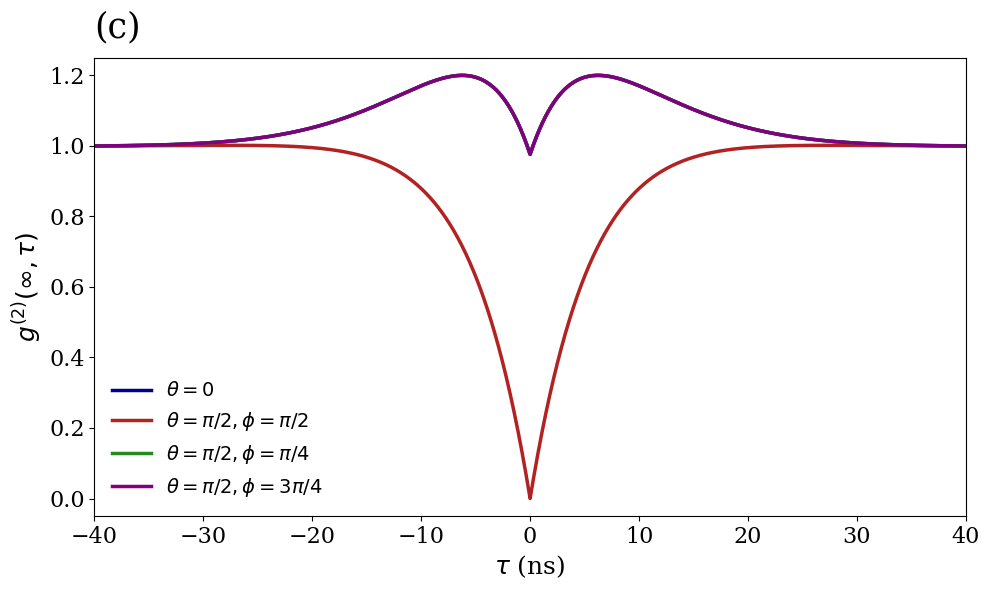

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sys_params import Constants, ConfigParameters, SystemParameters
from system_ops import SystemOperators
from rates import CombinedRates
from br_tensor import BlochRedfieldCalculator
from analysis import CoreAnalysis, OpticalDimerAnalysis

mpl.rcParams['text.usetex'] = False

# 1. System Initialization
config = ConfigParameters(
    config_name="ortho", 
    mode="polaron", 
    pump="sym", 
    integration_method="vectorised",
    data_dir="files/dipole_positions/" 
)

sys_params = SystemParameters(
    constants=Constants(), 
    config_params=config, 
    E_q1_eV=1.8, 
    E_q2_eV=1.8,
    T_opt=5800.0,
    T_vib=300.0
)
sys_params.calculate_parameters()

sys_params.gamma_p_1 = sys_params.gamma_q1
sys_params.gamma_p_2 = sys_params.gamma_q2

rates = CombinedRates(sys_params)
sys_ops = SystemOperators(sys_params, rates)

psi0 = np.array([1, 0, 0, 0], dtype=complex)
_, rho0 = sys_ops.initial_state(psi0)

a_ops_opt = [sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2]
a_ops_vib = [sys_ops.sz1, sys_ops.sz2]
a_ops_coup = [sys_ops.sp1 @ sys_ops.sm2, sys_ops.sm1 @ sys_ops.sp2]

br_calc = BlochRedfieldCalculator(
    system_params=sys_params, rates=rates, H=sys_ops.H,
    a_ops_opt=a_ops_opt, Gamma_opt=rates.Opt_rate(),
    a_ops_vib=a_ops_vib, Gamma_vib=rates.Vib_rate(),
    a_ops_coup=a_ops_coup, Gamma_coup=rates.Coup_rate(),
    P_vib=rates.P_weight()
)

# 2. Time Propagation
tf_g2 = 40000.0  # 40 ns integration window
steps_g2 = 1000

core_long = CoreAnalysis(
    system_params=sys_params, BR_calculator=br_calc, rates=rates, 
    final_time=tf_g2, steps=steps_g2, rho_init=rho0, ss_method='null_space'
)
dimer_long = OpticalDimerAnalysis(core_long)

# Helper function to extract unnormalized G2 array and map to normalized g2
def extract_normalized_g2(theta_val, phi_val):
    G2_array = dimer_long.G2_delay(theta_val, phi_val, theta_val, phi_val)
    if G2_array[-1] > 1e-12:
        g2_array = G2_array / G2_array[-1]
    else:
        g2_array = np.zeros_like(G2_array)
        
    g2_sym = np.append(np.flip(g2_array[1:]), g2_array)
    return g2_sym

# 3. Target Directions Extraction
# Blue: Perpendicular to both dipoles (along z-axis)
g2_z_sym = extract_normalized_g2(0.0, 0.0)

# Red: Along one of the dipoles (along y-axis)
g2_y_sym = extract_normalized_g2(np.pi/2, np.pi/2)

# Green: Diagonal q = (1, 1, 0)
g2_d1_sym = extract_normalized_g2(np.pi/2, np.pi/4)

# Purple: Anti-diagonal q = (1, -1, 0)
g2_d2_sym = extract_normalized_g2(np.pi/2, 3*np.pi/4)

# Build Symmetrized Time Axis
times_ns = core_long.times * 1.0e-3
times_sym = np.append(-np.flip(times_ns[1:]), times_ns)

# 4. Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(times_sym, g2_z_sym, color='darkblue', linewidth=2.5, label=r'$\theta=0$')
ax.plot(times_sym, g2_y_sym, color='firebrick', linewidth=2.5, label=r'$\theta=\pi/2, \phi=\pi/2$')
ax.plot(times_sym, g2_d1_sym, color='forestgreen', linewidth=2.5, label=r'$\theta=\pi/2, \phi=\pi/4$')
ax.plot(times_sym, g2_d2_sym, color='purple', linewidth=2.5, label=r'$\theta=\pi/2, \phi=3\pi/4$')

ax.set_xlabel(r'$\tau$ (ns)', fontsize=18)
ax.set_ylabel(r'$g^{(2)}(\infty, \tau)$', fontsize=18)
ax.set_xlim([-40, 40])
ax.set_ylim([-0.05, 1.25])
ax.tick_params(axis='both', labelsize=16)

ax.legend(loc='lower left', fontsize=14, frameon=False)
ax.set_title('(c)', loc='left', fontsize=25, pad=15)

plt.tight_layout()
plt.show()

To further understand the role of dipole interactions, we now explore an intermediate configuration between the parallel and orthogonal dimers, where the monomers are aligned at $45^\circ$ to each other. Just like the orthogonal case, projective measurements allow us to access any basis states, including the site basis. However, the key difference is that a finite dipole-dipole coupling in the $45^\circ$ dimer introduces new dynamics in the photon coincidences in the form of coherent oscillations in $g^{(2)}(\infty, \tau)$ around zero time delay.When photons are measured perpendicular to either one (red detector) or both dipoles (green detector), the coherent oscillations occur with a reduced amplitude, albeit at the same frequency determined by the dipole coupling. This results in a suppressed oscillation amplitude when the contributions from both polarization components are combined. The coherent oscillations occur on timescales determined by the renormalized dipole-dipole coupling $J'_{1,2}$ and persist within the electronic coherence lifetime.

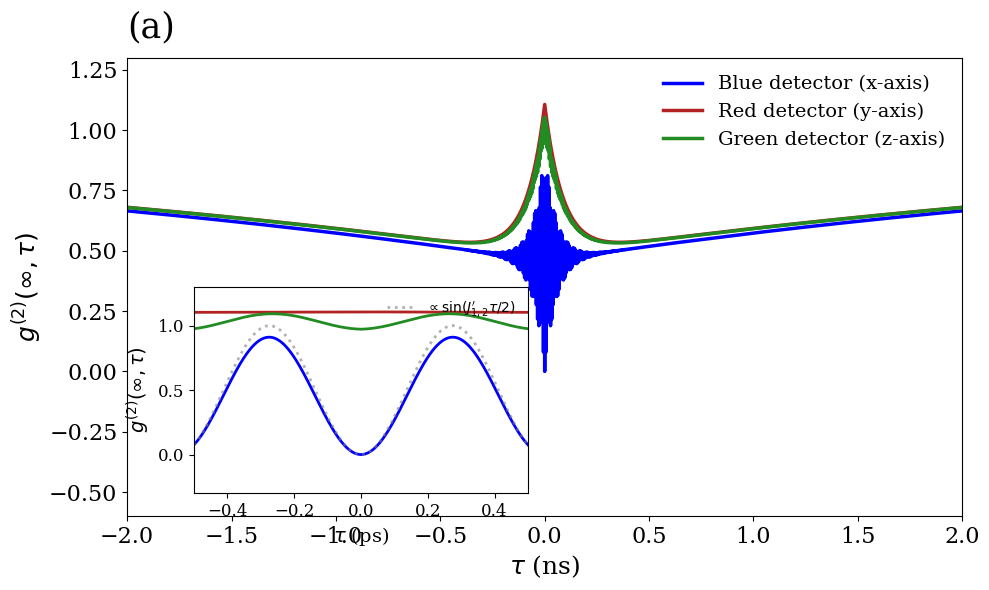

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sys_params import Constants, ConfigParameters, SystemParameters
from system_ops import SystemOperators
from rates import CombinedRates
from br_tensor import BlochRedfieldCalculator
from analysis import CoreAnalysis, OpticalDimerAnalysis

mpl.rcParams['text.usetex'] = False
 

# 2. System Initialization (Base Configuration)
config = ConfigParameters(
    config_name="45", 
    mode="polaron", 
    pump="sym", 
    integration_method="vectorised",
    data_dir="files/dipole_positions/" 
)

constants = Constants()
sys_params = SystemParameters(
    constants=constants, 
    config_params=config, 
    E_q1_eV=1.8, 
    E_q2_eV=1.8,
    T_opt=5800.0,
    T_vib=300.0
)
sys_params.calculate_parameters()

sys_params.gamma_p_1 = sys_params.gamma_q1
sys_params.gamma_p_2 = sys_params.gamma_q2

rates = CombinedRates(sys_params)
sys_ops = SystemOperators(sys_params, rates)

psi0 = np.array([1, 0, 0, 0], dtype=complex)
_, rho0 = sys_ops.initial_state(psi0)

a_ops_opt = [sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2]
a_ops_vib = [sys_ops.sz1, sys_ops.sz2]
a_ops_coup = [sys_ops.sp1 @ sys_ops.sm2, sys_ops.sm1 @ sys_ops.sp2]

br_calc = BlochRedfieldCalculator(
    system_params=sys_params, rates=rates, H=sys_ops.H,
    a_ops_opt=a_ops_opt, Gamma_opt=rates.Opt_rate(),
    a_ops_vib=a_ops_vib, Gamma_vib=rates.Vib_rate(),
    a_ops_coup=a_ops_coup, Gamma_coup=rates.Coup_rate(),
    P_vib=rates.P_weight()
)

# 4. Extract Steady-State Asymptotes
core_ss = CoreAnalysis(
    system_params=sys_params, BR_calculator=br_calc, rates=rates, 
    final_time=20000.0, steps=100, rho_init=rho0, ss_method='null_space'
)
dimer_ss = OpticalDimerAnalysis(core_ss)

ss_blue = dimer_ss.G2_delay(np.pi/2, 0.0, np.pi/2, 0.0)[-1]
ss_red = dimer_ss.G2_delay(np.pi/2, np.pi/2, np.pi/2, np.pi/2)[-1]
ss_green = dimer_ss.G2_delay(0.0, 0.0, 0.0, 0.0)[-1]

# Instantiates a fresh CoreAnalysis engine for the specific integration window
def get_sym_g2(tf, steps):
    core_engine = CoreAnalysis(
        system_params=sys_params, BR_calculator=br_calc, rates=rates, 
        final_time=tf, steps=steps, rho_init=rho0, ss_method='null_space'
    )
    dimer_engine = OpticalDimerAnalysis(core_engine)
    
    g2_blue = dimer_engine.G2_delay(np.pi/2, 0.0, np.pi/2, 0.0) / ss_blue
    g2_red = dimer_engine.G2_delay(np.pi/2, np.pi/2, np.pi/2, np.pi/2) / ss_red
    g2_green = dimer_engine.G2_delay(0.0, 0.0, 0.0, 0.0) / ss_green
    
    times = core_engine.times
    times_sym = np.append(-np.flip(times[1:]), times)
    
    g2_blue_sym = np.append(np.flip(g2_blue[1:]), g2_blue)
    g2_red_sym = np.append(np.flip(g2_red[1:]), g2_red)
    g2_green_sym = np.append(np.flip(g2_green[1:]), g2_green)
    
    return times_sym, g2_blue_sym, g2_red_sym, g2_green_sym

# 5. Execute Nanosecond & Picosecond Propagations
times_ns_sym, g2_blue_ns, g2_red_ns, g2_green_ns = get_sym_g2(2000.0, 1000)
times_ps_sym, g2_blue_ps, g2_red_ps, g2_green_ps = get_sym_g2(0.5, 500)

times_ns_sym = times_ns_sym * 1e-3  # Convert ns axis

# 6. Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# --- Main Plot (Nanosecond Scale) ---
ax.plot(times_ns_sym, g2_blue_ns, color='blue', linewidth=2.5, label='Blue detector (x-axis)')
ax.plot(times_ns_sym, g2_red_ns, color='firebrick', linewidth=2.5, label='Red detector (y-axis)')
ax.plot(times_ns_sym, g2_green_ns, color='forestgreen', linewidth=2.5, label='Green detector (z-axis)')

ax.set_xlabel(r'$\tau$ (ns)', fontsize=18)
ax.set_ylabel(r'$g^{(2)}(\infty, \tau)$', fontsize=18)
ax.set_xlim([-2.0, 2.0])
# Extending y-axis below 0 to create negative space for the inset
ax.set_ylim([-0.6, 1.3])
ax.tick_params(axis='both', labelsize=16)

ax.legend(loc='upper right', fontsize=14, frameon=False)
ax.set_title('(a)', loc='left', fontsize=25, pad=15)


# --- Inset Plot (Picosecond Scale) ---
axins = ax.inset_axes([0.08, 0.05, 0.4, 0.45])
axins.plot(times_ps_sym, g2_blue_ps, color='blue', linewidth=2)
axins.plot(times_ps_sym, g2_red_ps, color='firebrick', linewidth=2)
axins.plot(times_ps_sym, g2_green_ps, color='forestgreen', linewidth=2)

kappa_0 = rates.kappa() 
J_prime_ps = sys_params.J * (kappa_0**2) 

# Scaled and shifted strictly for visual frequency comparison within the inset
gray_curve = 1.0 * np.sin(J_prime_ps * times_ps_sym / 2)**2
axins.plot(times_ps_sym, gray_curve, color='gray', linestyle=':', linewidth=2, alpha=0.6, label=r'$\propto \sin(J_{1,2}^{\prime}\tau/2)$')

axins.set_xlabel(r'$\tau$ (ps)', fontsize=14)
axins.set_ylabel(r'$g^{(2)}(\infty, \tau)$', fontsize=14)
axins.set_xlim([-0.5, 0.5])
axins.set_ylim([-0.3, 1.3])
axins.tick_params(axis='both', labelsize=12)
axins.legend(loc='upper right', fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

In [8]:



# import warnings
# import numpy as np
# import matplotlib.pyplot as plt

# from sys_params import Constants, ConfigParameters, SystemParameters
# from system_ops import SystemOperators
# from rates import CombinedRates
# from br_tensor import BlochRedfieldCalculator

# def intensity_spectrum_benchmark(Omega_ratio, detuning_range=[-1.5, 1.5], num_points=500):
#     """
#     Evaluates the steady-state mean intensity vs laser detuning.
#     Forces analytical limits (beta = pi/4, gamma/R = 10^-2) and bypasses geometry.
#     """
#     config = ConfigParameters(config_name="H", mode="weak", pump="coh")
#     constants = Constants()
    
#     # 1. Define forced analytical parameters
#     omega_q = 1000.0  # Base frequency
#     R = 1.0           # Set collective coupling scale R = 1
#     gamma = 1e-2 * R  # Force gamma/R = 10^-2 
    
#     # Enforce beta = pi/4 -> delta = J, R = sqrt(2)J
#     J_val = R / np.sqrt(2)
#     beta = np.pi / 4.0
#     Omega = Omega_ratio * R

#     delta_vals = np.linspace(detuning_range[0] * R, detuning_range[1] * R, num_points)
#     num_intensity = np.zeros(num_points)
#     ana_intensity = np.zeros(num_points)

#     # 2. Analytical constants
#     gamma_plus = gamma + gamma * np.cos(beta)
#     gamma_minus = gamma - gamma * np.cos(beta)
#     Omega_plus = Omega * np.sqrt(1 + np.cos(beta))
#     Omega_minus = Omega * np.sqrt(1 - np.cos(beta))
#     Omega_2p = -2 * Omega**2 / R * np.cos(beta)

#     # 3. Initialize System Parameters
#     sys_params = SystemParameters(
#         constants=constants, config_params=config, E_q1_eV=1.8, E_q2_eV=1.8, omega_L=omega_q, r_nm=0.1
#     )
#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore")
#         sys_params.calculate_parameters()
    
#     # 4. Override parameters to bypass physical geometry limitations
#     sys_params.J = J_val
#     sys_params.omega_q1 = omega_q - J_val
#     sys_params.omega_q2 = omega_q + J_val
#     sys_params.gamma_q1 = gamma
#     sys_params.gamma_q2 = gamma
#     sys_params.kappa_0 = 1.0  # Forces full collective dissipation gamma_12 = gamma
#     sys_params.Omega_1 = Omega
#     sys_params.Omega_2 = Omega
    
#     # Disable thermal excitations to match the analytical vacuum-induced model
#     sys_params.T_opt = 0.0
#     sys_params.T_vib = 0.0

#     # 5. Integration Loop
#     for i, delta in enumerate(delta_vals):
#         # Sweep the laser frequency
#         sys_params.omega_L = omega_q - delta
        
#         rates = CombinedRates(sys_params)
#         sys_ops = SystemOperators(sys_params, rates)
        
#         with warnings.catch_warnings():
#             warnings.simplefilter("ignore")
#             br_calc = BlochRedfieldCalculator(
#                 system_params=sys_params, rates=rates, H=sys_ops.H,
#                 a_ops_opt=[sys_ops.sp1, sys_ops.sm1, sys_ops.sp2, sys_ops.sm2], Gamma_opt=rates.Opt_rate(),
#                 a_ops_vib=[sys_ops.sz1, sys_ops.sz2], Gamma_vib=rates.Vib_rate()
#             )
            
#             # Monkey-patch the spatial interaction tensor to return exactly 1s
#             # This completely bypasses the sin(kr)/kr division-by-zero NaNs.
#             br_calc.mathcal_F = lambda k: np.ones((4, 4), dtype=complex)
#             L = br_calc.total_BR_tensor()
        
#         # --- ROBUST STEADY STATE EIGEN-SOLVER ---
#         # Evaluates the exact zero-eigenvalue vector of the Liouvillian superoperator
#         evals, evecs = np.linalg.eig(L)
#         zero_idx = np.argmin(np.abs(evals))
#         rho_ss_vec = evecs[:, zero_idx]
        
#         rho_ss = rho_ss_vec.reshape((4, 4))
#         rho_ss /= np.trace(rho_ss)  # Enforce Trace = 1
            
#         # Extract numerical intensity
#         ekets = sys_ops.ekets
#         sm1_eig = ekets.conj().T @ sys_ops.sm1 @ ekets
#         sm2_eig = ekets.conj().T @ sys_ops.sm2 @ ekets
#         sp1_eig = ekets.conj().T @ sys_ops.sp1 @ ekets
#         sp2_eig = ekets.conj().T @ sys_ops.sp2 @ ekets
        
#         I_op = (sp1_eig + sp2_eig) @ (sm1_eig + sm2_eig)
#         num_intensity[i] = np.real(np.trace(I_op @ rho_ss))
        
#         # --- ANALYTICAL EVALUATION ---
#         chi = (2 * (gamma**2 * delta**2 + (delta**2 + 2 * Omega**2)**2) 
#                + gamma**2 * R**2 * np.cos(2 * beta) 
#                + R**2 * (gamma**2 - 4 * delta**2 + 8 * Omega**2) 
#                + 2 * R**4 - 4 * delta * R * np.cos(beta) * (gamma**2 + 4 * Omega**2))
        
#         zeta_plus = gamma_plus**2 + 4 * (delta + R)**2 + 8 * Omega_plus**2
#         zeta_minus = gamma_minus**2 + 4 * (delta - R)**2 + 8 * Omega_minus**2
        
#         I_2 = 4 * Omega_2p**2 / (gamma**2 + 4 * delta**2 + 4 * Omega_2p**2)
#         I_1_a = 4 * Omega**2 * (R**2 - delta**2 + 2 * Omega**2) * np.sin(beta)**2 / chi if chi != 0 else 0
        
#         # Exact interference formula (minus sign defines the destructive interference)
#         I_1_b = (4 / (zeta_minus * zeta_plus)) * (4 * Omega_plus**2 * Omega_minus**2 
#                 + Omega_plus**2 * (1 + np.cos(beta)) * zeta_minus 
#                 - Omega_minus**2 * (1 - np.cos(beta)) * zeta_plus)
                
#         # Absolute value prevents the exact zero crossing from returning negative intensities
#         ana_intensity[i] = np.abs(I_2 + I_1_a + I_1_b)

#     return delta_vals / R, num_intensity, ana_intensity

# # =====================================================================
# # RUN LIMITS
# # =====================================================================
# print("Evaluating Omega/R = 1.0...")
# deltas, num_I_1, ana_I_1 = intensity_spectrum_benchmark(Omega_ratio=1.0)

# print("Evaluating Omega/R = 0.1...")
# deltas, num_I_01, ana_I_01 = intensity_spectrum_benchmark(Omega_ratio=0.1)

# print("Evaluating Omega/R = 0.01...")
# deltas, num_I_001, ana_I_001 = intensity_spectrum_benchmark(Omega_ratio=0.01)

# # =====================================================================
# # PLOTTING (Exact color formatting to match referenced image)
# # =====================================================================
# plt.figure(figsize=(14, 6))

# # Omega/R = 1.0
# plt.semilogy(deltas, ana_I_1, color='purple', linestyle='--', linewidth=2.5, label=r'Analytical $\Omega/R = 1$')
# plt.semilogy(deltas, num_I_1, color='#C482C2', linestyle='-', linewidth=2, label=r'Numerical $\Omega/R = 1$')

# # Omega/R = 0.1
# plt.semilogy(deltas, ana_I_01, color='red', linestyle='--', linewidth=2.5, label=r'Analytical $\Omega/R = 0.1$')
# plt.semilogy(deltas, num_I_01, color='#FF847C', linestyle='-', linewidth=2, label=r'Numerical $\Omega/R = 0.1$')

# # Omega/R = 0.01
# plt.semilogy(deltas, ana_I_001, color='royalblue', linestyle='--', linewidth=2.5, label=r'Analytical $\Omega/R = 0.01$')
# plt.semilogy(deltas, num_I_001, color='#8BA4F9', linestyle='-', linewidth=2, label=r'Numerical $\Omega/R = 0.01$')

# # Topography boundaries and Dip
# plt.axvline(0, color='gray', linewidth=0.8)
# plt.axvline(-1, color='gray', linewidth=0.8)
# plt.axvline(1, color='gray', linewidth=0.8)
# plt.axvline(np.cos(np.pi/4), color='blue', linestyle=':', linewidth=1.5, label=r'Dip $\Delta/R = \cos(\pi/4)$')

# plt.xlabel(r'$\Delta/R$', fontsize=18)
# plt.ylabel(r'$\langle(\hat{\sigma}_1^\dagger + \hat{\sigma}_2^\dagger)(\hat{\sigma}_1 + \hat{\sigma}_2)\rangle$', fontsize=18)
# plt.title(r'Steady-State Mean Intensity Spectrum ($\beta = \pi/4$)', fontsize=18)

# plt.xlim([-1.5, 1.5])
# plt.ylim([1e-6, 1e1])

# plt.tick_params(axis='both', which='major', labelsize=14)
# plt.legend(frameon=False, fontsize=13, loc='lower left')
# plt.tight_layout()
# plt.show()